# 02 — Build Network (Road Graph + Flood Exposure Features)

This notebook focuses on **network construction** and **road-segment hazard feature engineering**. The goal is to produce a reusable evacuation road network dataset and attach raster-derived flood exposure features to each road segment, per month.

Outputs:
- Road graph checkpoints (GraphML / GPKG)
- Edge GeoDataFrame with per-month features:
  - `p_hazard_<month>`: fraction of sampled points along edge that fall on wet classes
  - `p_buffer_hazard_<month>`: fraction of wet pixels in a buffer polygon around the edge
- Saved figures (maps + histograms) to `outputs/graphs/`

Notes:
- The **buffer-based** raster feature is more expensive than point-sampling. It is implemented here for parity with the original notebook EDA and will be moved to `src/raster_features.py` later.


In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().resolve().parent)  # notebooks/ -> project root
print("New CWD:", Path.cwd().resolve())

New CWD: C:\Users\nachi\Data\GitHubProjects\Barpeta flooding\barpeta_evac


In [2]:
# --- Setup ---
from pathlib import Path
import pandas as pd
import geopandas as gpd

from src.config import MONTH_KEYS, WET_CLASS_VALUES, EVAC_DRIVABLE_HIGHWAYS
from src import io, roads, viz
from src import raster_features as rf

OUT_GRAPHS = Path("outputs/graphs")
OUT_TABLES = Path("outputs/tables")
OUT_GRAPHS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("MONTH_KEYS:", MONTH_KEYS)
print("WET_CLASS_VALUES:", WET_CLASS_VALUES)
print("EVAC_DRIVABLE_HIGHWAYS:", sorted(EVAC_DRIVABLE_HIGHWAYS))


MONTH_KEYS: ('jan', 'may', 'oct')
WET_CLASS_VALUES: {0, 3}
EVAC_DRIVABLE_HIGHWAYS: ['primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link']


## 1) Open monthly LULC rasters
We use these rasters as the hazard surface. All months are assumed to share the same CRS and bounds.


In [3]:
lulc_srcs = io.open_all_lulc(io.LULC_TIF_PATHS)

# Raster bounds (used for bbox / network download)
sample_month = MONTH_KEYS[0]
b = lulc_srcs[sample_month].bounds
left, bottom, right, top = b.left, b.bottom, b.right, b.top
bbox = (top, bottom, right, left)  # (north, south, east, west)

print("Raster CRS:", lulc_srcs[sample_month].crs)
print("Raster bounds:", b)
print("bbox (north, south, east, west):", bbox)


Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=90.65321740233628, bottom=26.089680965154855, right=91.2900331072486, top=26.66541123074705)
bbox (north, south, east, west): (26.66541123074705, 26.089680965154855, 91.2900331072486, 90.65321740233628)


## 2) Download and prepare road graph
Steps:
1. Download OSM graph using raster bounds.
2. Filter to evacuation-relevant highway types.
3. Extract largest connected component (LCC).
4. Convert to node/edge GeoDataFrames.
5. Save graph checkpoints.


In [4]:
aoi = gpd.read_file("data/processed/barpeta_aoi.geojson")
aoi = aoi.set_crs("EPSG:4326", allow_override=True)  # safe guard

In [5]:
# bbox for OSMnx: (north, south, east, west)
left=90.65321740233628
bottom=26.089680965154855
right=91.2900331072486
top=26.66541123074705

bbox=(left, bottom, right, top)

print("bbox (west, south, east, north):", bbox)

# Download graph (broad) then filter to evac-drivable highways
G_all = roads.download_graph_from_bbox(bbox, network_type="all", simplify=True, retain_all=True)

G_drive = roads.filter_graph_by_highway(G_all, EVAC_DRIVABLE_HIGHWAYS)
G_drive_lcc = roads.largest_connected_component(G_drive)

gdf_nodes, gdf_edges = roads.graph_to_gdfs(G_drive_lcc)

print("Nodes:", gdf_nodes.shape, "Edges:", gdf_edges.shape)
display(gdf_edges.head(2))


bbox (west, south, east, north): (90.65321740233628, 26.089680965154855, 91.2900331072486, 26.66541123074705)
Nodes: (1114, 5) Edges: (2389, 11)


osmid   highway  oneway reversed       length  \
u          v          key                                                      
5775679488 5775679399 0    609803339  tertiary   False    False   892.554258   
           5775679511 0    609803341  tertiary   False    False  2038.601565   

                                                                    geometry  \
u          v          key                                                      
5775679488 5775679399 0    LINESTRING (91.20089 26.54229, 91.20366 26.542...   
           5775679511 0    LINESTRING (91.20089 26.54229, 91.20132 26.540...   

                          name  ref bridge access lanes  
u          v          key                                
5775679488 5775679399 0    NaN  NaN    NaN    NaN   NaN  
           5775679511 0    NaN  NaN    NaN    NaN   NaN

In [6]:
# Save graph checkpoints (recommended)
from pathlib import Path

roads.save_graph_gpkg(G_drive_lcc, Path("outputs/tables/roads_drive_lcc.gpkg"))
roads.save_graphml(G_drive_lcc, Path("outputs/tables/roads_drive_lcc.graphml"))

print("Saved graph to outputs/tables/")


Saved graph to outputs/tables/


## 3) Edge hazard by sampling along the line (`p_hazard_<month>`)
This feature is computed by densifying each edge line in a metric CRS, transforming points to raster CRS, and sampling raster values. This is a repeat of the analysis done in the EDA. However, it is expanded upon in the following segment. 

Definition:
- `p_hazard_<month>` = fraction of sampled points whose raster class ∈ `WET_CLASS_VALUES`.

Expected NaNs:
- Edge lies outside the LULC coverage or samples only nodata.


In [7]:
# Compute p_hazard_<month>
for m in MONTH_KEYS:
    src = lulc_srcs[m]
    out_col = f"p_hazard_{m}"
    gdf_edges = rf.add_raster_hazard_feature_one_month(
        gdf_edges,
        src,
        out_col=out_col,
        step_m=25.0,
        hazard_classes=set(WET_CLASS_VALUES),
        nodata_values={src.nodata} if src.nodata is not None else None,
    )
    print(out_col, "NaN:", int(gdf_edges[out_col].isna().sum()), "of", len(gdf_edges))


p_hazard_jan NaN: 963 of 2389
p_hazard_may NaN: 963 of 2389
p_hazard_oct NaN: 963 of 2389


### Visualize `p_hazard_<month>`
- Map: roads over raster, colored by `p_hazard_<month>`
- Histogram: distribution of `p_hazard_<month>`


Saved: outputs\graphs\roads_line_sampling__jan.png
Saved: outputs\graphs\hist_p_hazard_jan.png
Saved: outputs\graphs\roads_line_sampling__may.png
Saved: outputs\graphs\hist_p_hazard_may.png
Saved: outputs\graphs\roads_line_sampling__oct.png
Saved: outputs\graphs\hist_p_hazard_oct.png


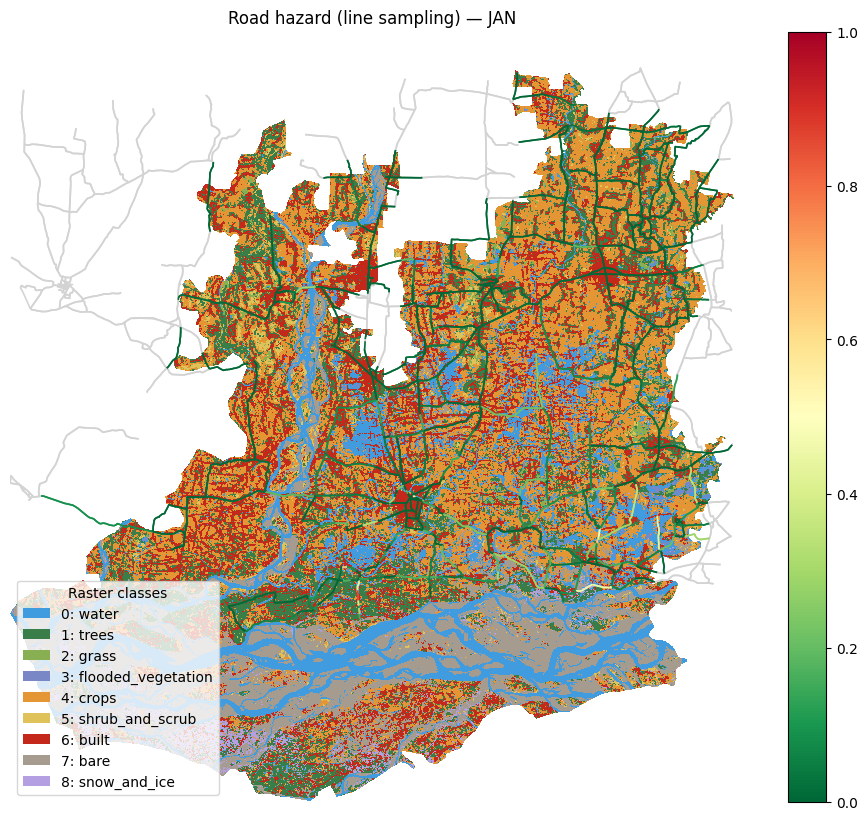

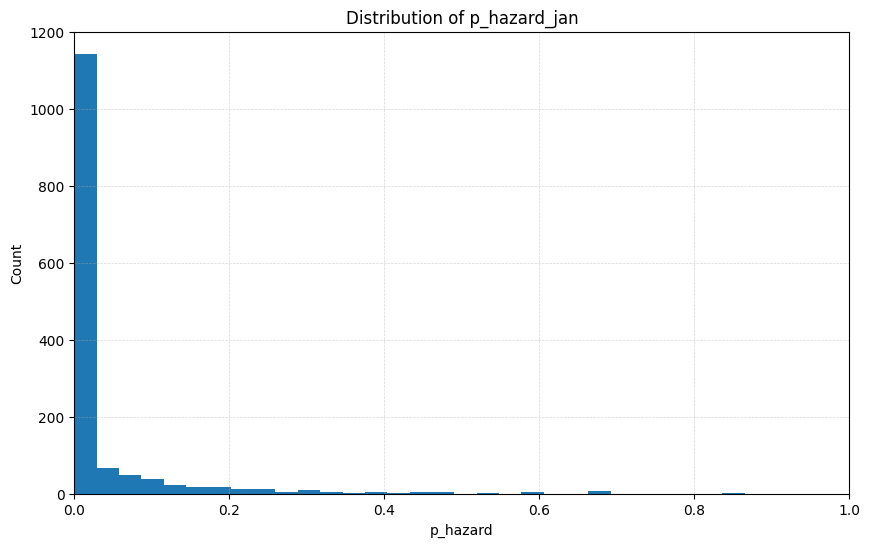

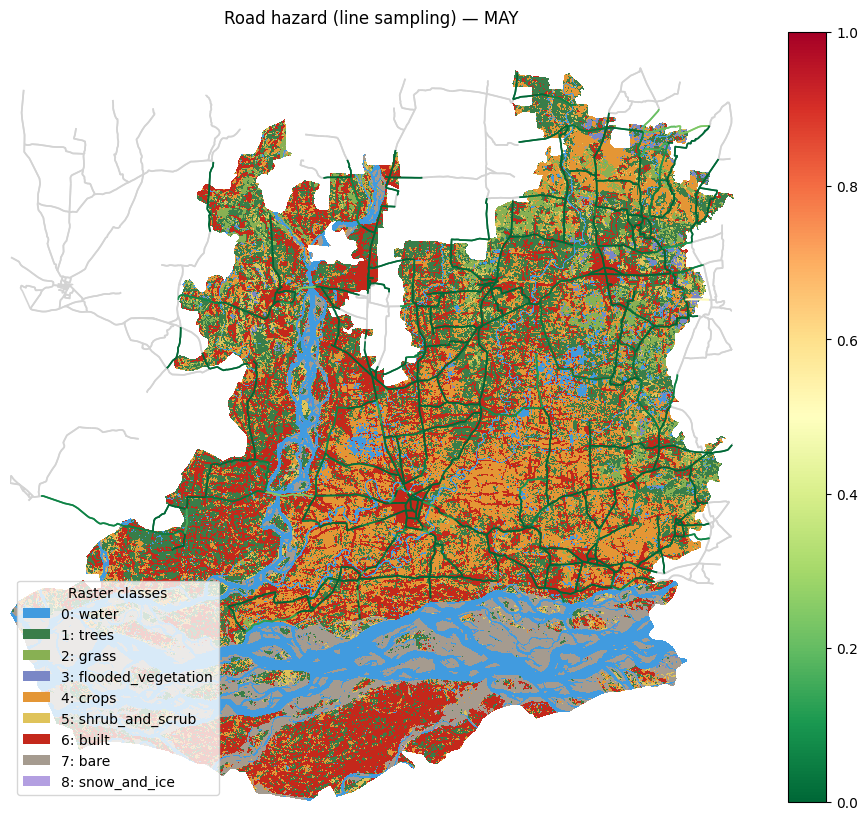

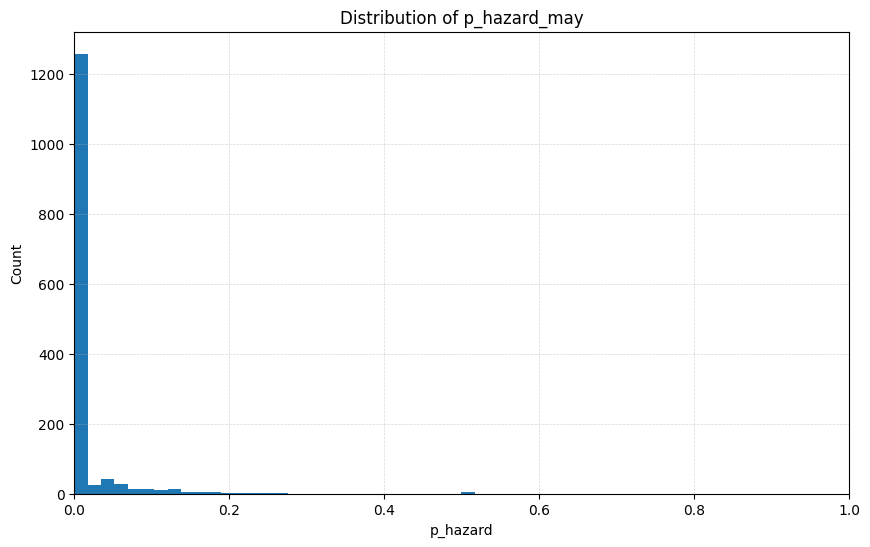

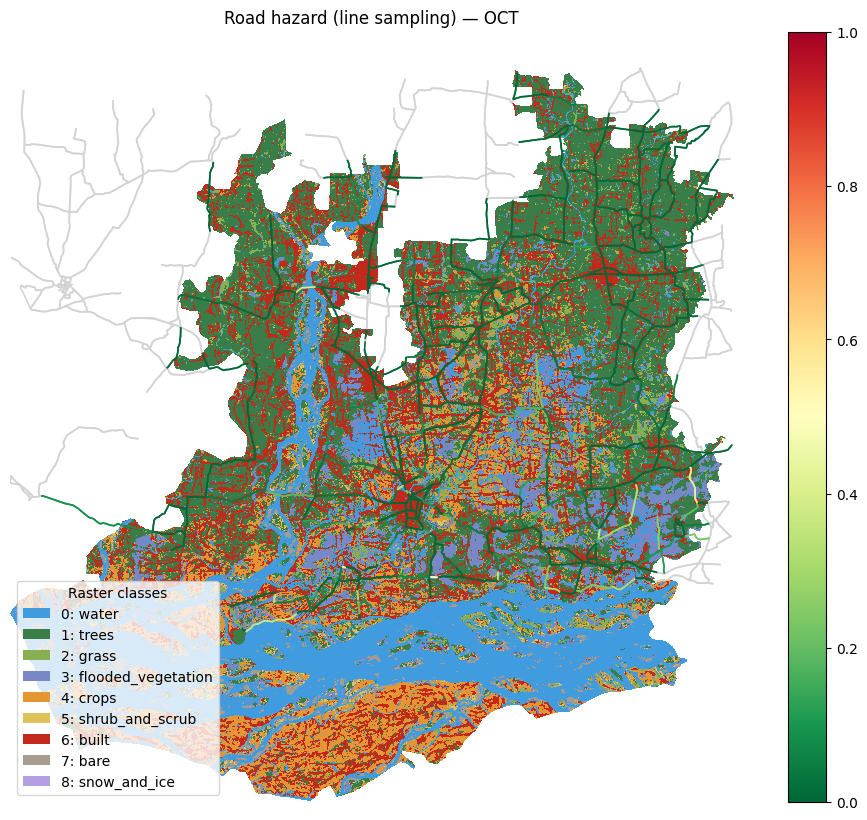

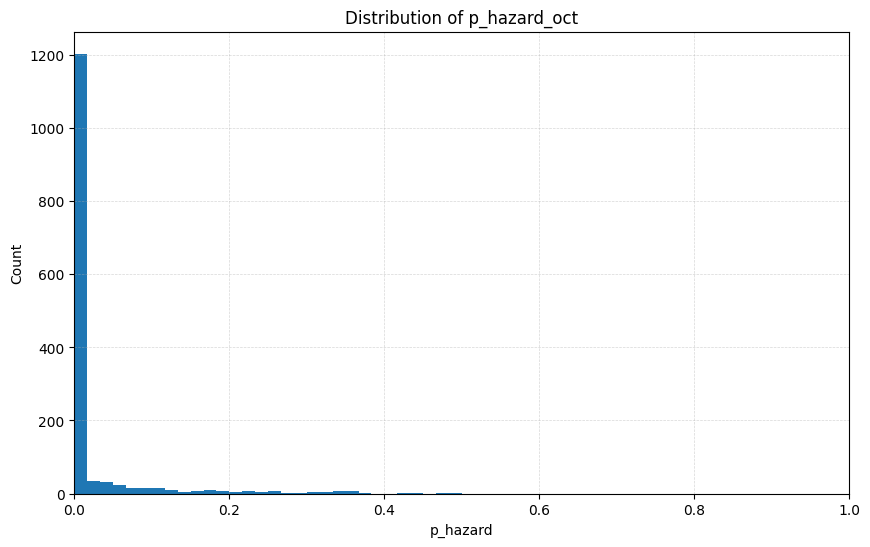

In [8]:
for m in MONTH_KEYS:
    col = f"p_hazard_{m}"
    fig, ax, saved = viz.plot_roads_over_tif(
        gdf_edges,
        lulc_srcs[m],
        hazard_col=col,
        title=f"Road hazard (line sampling) — {m.upper()}",
        save=True,
        out_dir=OUT_GRAPHS,
        name=f"roads_line_sampling__{m}",
    )
    print("Saved:", saved)

    fig, ax, saved = viz.plot_series_histogram(
        gdf_edges[col],
        title=f"Distribution of {col}",
        xlabel="p_hazard",
        bins=30,
        xlim=(0, 1),
        save=True,
        out_dir=OUT_GRAPHS,
        name=f"hist_{col}",
    )
    print("Saved:", saved)


## 4) Edge hazard by buffered polygon (`p_buffer_hazard_<month>`)
The initial hazard calculation only accounts for LULC pixels that directly lie on the road segment. However, the flooding hazard to a road segment also lies in the area around it. Hence, a buffer area around the road segment needs to be calculated. 

This feature evaluates **pixels around a road segment**.

Definition:
- Create a buffer polygon around each road segment (in meters).
- Compute the fraction of raster pixels inside the buffer that are wet.

This is closer to the idea of “road corridor flood risk” than point-sampling.

Performance note:
- Computing this for all edges can be slow.
- Use `MAX_EDGES` for testing; set to `None` for full run.


In [9]:
# Buffer-hazard helper (implemented in-notebook for now; migrate later to src/raster_features.py)

import numpy as np
import geopandas as gpd
from rasterio.windows import from_bounds, Window
from rasterio.features import geometry_mask

def add_buffer_hazard_feature_one_month(
    gdf_edges: gpd.GeoDataFrame,
    src,
    *,
    out_col: str,
    buffer_m: float = 30.0,
    hazard_classes=set(WET_CLASS_VALUES),
    nodata_values=None,
    max_edges: int | None = 5000,
    all_touched: bool = True,
):
    if gdf_edges.crs is None:
        raise ValueError("gdf_edges.crs is None.")
    if src.crs is None:
        raise ValueError("Raster src.crs is None.")

    # nodata set
    if nodata_values is None:
        nodata_values = set()
        if src.nodata is not None:
            nodata_values.add(int(src.nodata))
    else:
        nodata_values = set(int(x) for x in nodata_values if x is not None)

    # Work in metric CRS for buffering
    utm_crs = gdf_edges.estimate_utm_crs()
    edges_m = gdf_edges.to_crs(utm_crs).copy()
    edges_m["__buf__"] = edges_m.geometry.buffer(buffer_m)

    # Convert buffered polygons back to raster CRS
    buf_polys = gpd.GeoSeries(edges_m["__buf__"], crs=utm_crs).to_crs(src.crs)

    # Prepare output
    out = gdf_edges.copy()
    out[out_col] = np.nan

    # Optional subsetting
    if max_edges is not None:
        idx = out.index[:max_edges]
    else:
        idx = out.index

    full = Window(0, 0, src.width, src.height)

    for i in idx:
        geom = buf_polys.loc[i]
        if geom is None or geom.is_empty:
            continue

        minx, miny, maxx, maxy = geom.bounds
        w = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        try:
            w = w.intersection(full)
        except Exception:
            continue

        w = w.round_offsets(op="floor").round_lengths(op="ceil")
        if w.width < 1 or w.height < 1:
            continue

        arr = src.read(1, window=w).astype(float)
        transform = src.window_transform(w)

        inside = geometry_mask([geom], out_shape=arr.shape, transform=transform, invert=True, all_touched=all_touched)
        vals = arr[inside]
        if vals.size == 0:
            continue

        # drop nodata
        if len(nodata_values) > 0:
            for nd in nodata_values:
                vals = vals[vals != float(nd)]
        if vals.size == 0:
            continue

        vi = vals.astype(int)
        out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))

    return out


A road can be risky if the surrounding corridor is wet but only the centerline is dry. This can still disrupt avacuation usability. Classification noise at the exact centerline is less important than corridor condition for moving traffic.

In [10]:
# Compute p_buffer_hazard_<month>
BUFFER_M = 30.0
MAX_EDGES = None  # set to None for full computation (may be slow)

for m in MONTH_KEYS:
    src = lulc_srcs[m]
    col = f"p_buffer_hazard_{m}"
    gdf_edges = add_buffer_hazard_feature_one_month(
        gdf_edges,
        src,
        out_col=col,
        buffer_m=BUFFER_M,
        hazard_classes=set(WET_CLASS_VALUES),
        nodata_values={src.nodata} if src.nodata is not None else None,
        max_edges=MAX_EDGES,
        all_touched=True,
    )
    print(col, "NaN:", int(gdf_edges[col].isna().sum()), "of", len(gdf_edges))
#suppress warnings later

C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  ou

p_buffer_hazard_jan NaN: 956 of 2389


C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  ou

p_buffer_hazard_may NaN: 956 of 2389


C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  ou

p_buffer_hazard_oct NaN: 956 of 2389


C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  out.loc[i, out_col] = float(np.mean(np.isin(vi, list(hazard_classes))))
C:\Users\nachi\AppData\Local\Temp\ipykernel_14128\2506853054.py:84: PerformanceWarning: indexing past lexsort depth may impact performance.
  ou

### Visualize `p_buffer_hazard_<month>`
- Histogram distribution
- Threshold map (thr=0.2): risky vs safe

Reminder: If `MAX_EDGES`!= None, plots reflect only the processed subset.


Saved: outputs\graphs\hist_p_buffer_hazard_jan_buf_30m.png
Saved: outputs\graphs\roads_threshold_p_buffer_hazard_jan_thr_0p2.png
Saved: outputs\graphs\hist_p_buffer_hazard_may_buf_30m.png
Saved: outputs\graphs\roads_threshold_p_buffer_hazard_may_thr_0p2.png
Saved: outputs\graphs\hist_p_buffer_hazard_oct_buf_30m.png
Saved: outputs\graphs\roads_threshold_p_buffer_hazard_oct_thr_0p2.png


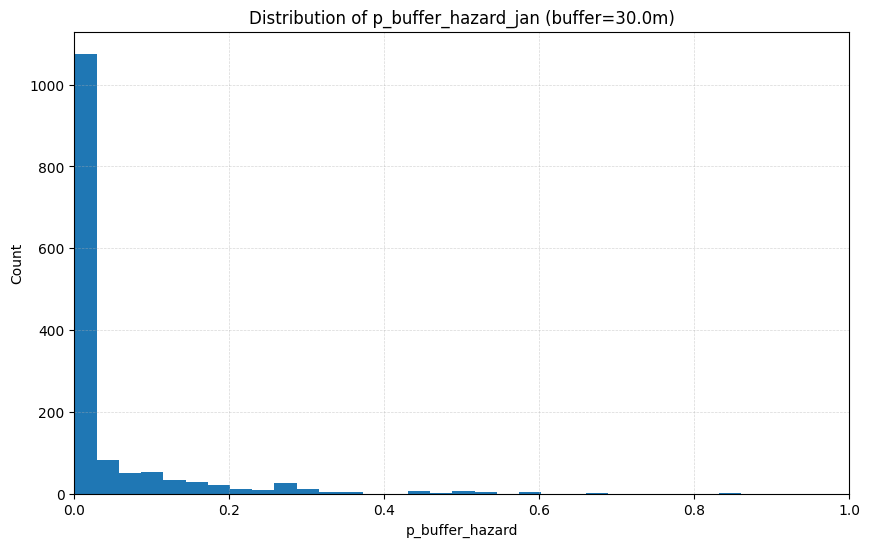

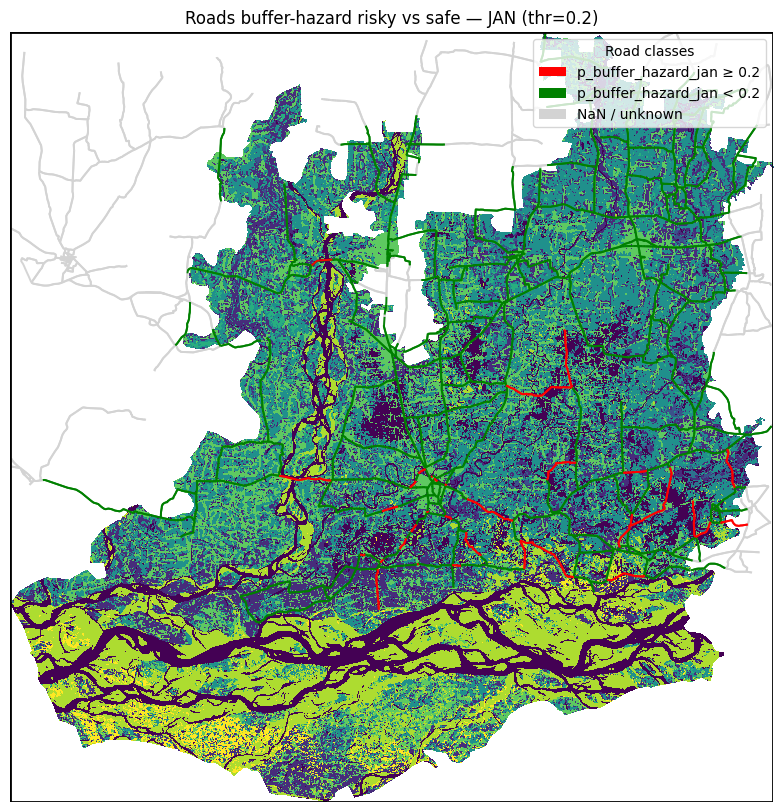

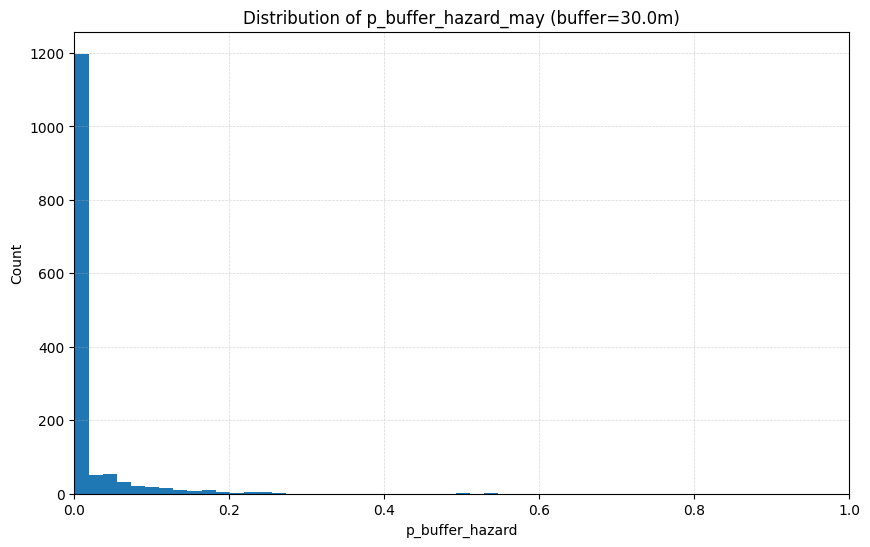

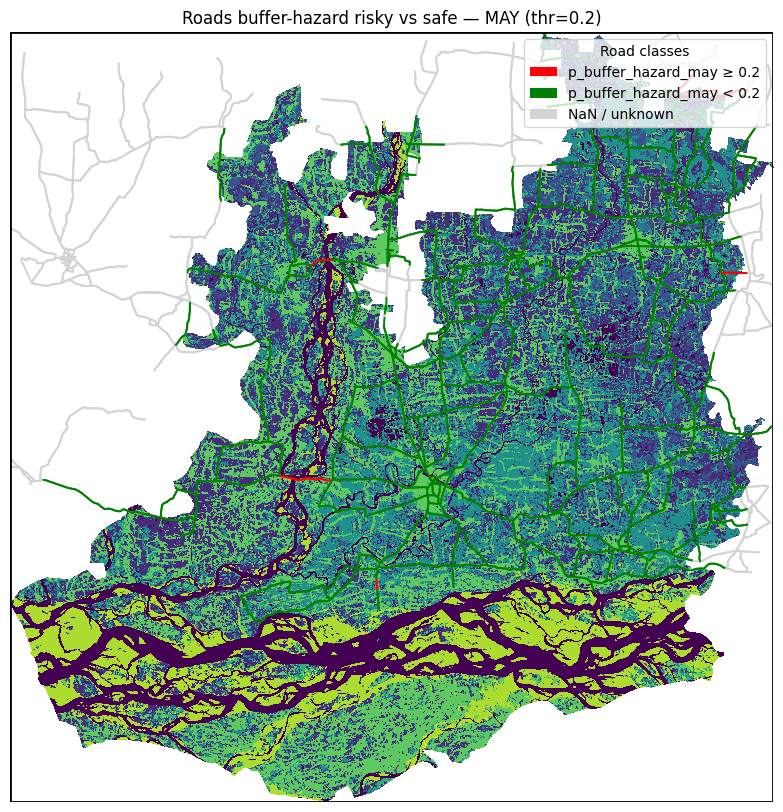

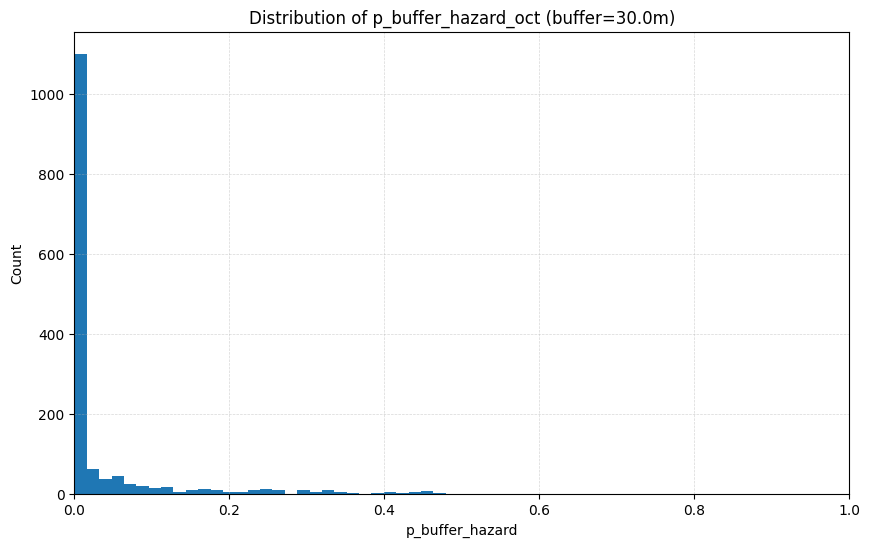

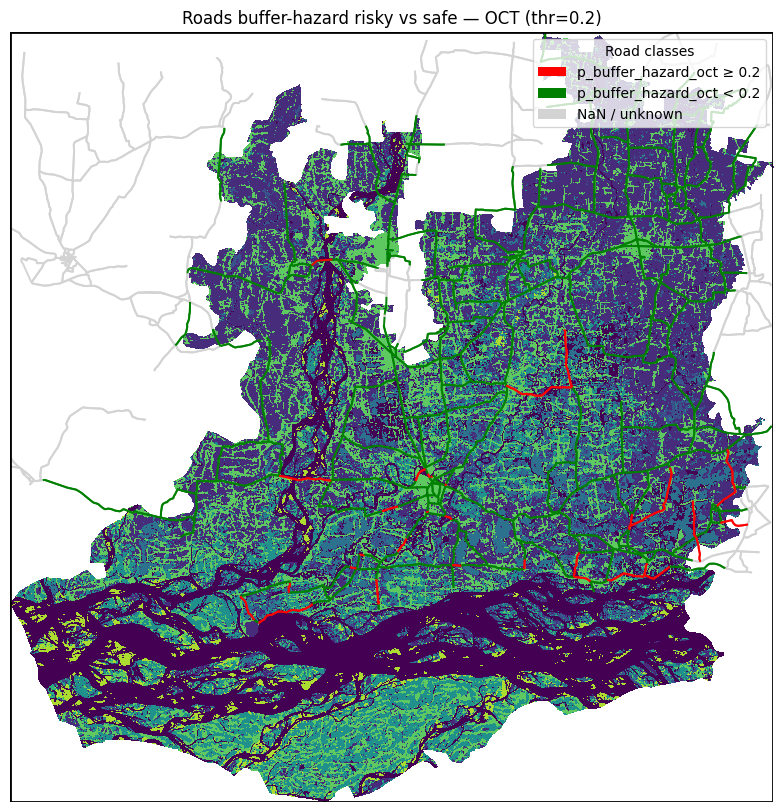

In [11]:
for m in MONTH_KEYS:
    col = f"p_buffer_hazard_{m}"

    fig, ax, saved = viz.plot_series_histogram(
        gdf_edges[col],
        title=f"Distribution of {col} (buffer={BUFFER_M}m)",
        xlabel="p_buffer_hazard",
        bins=30,
        xlim=(0, 1),
        save=True,
        out_dir=OUT_GRAPHS,
        name=f"hist_{col}_buf_{int(BUFFER_M)}m",
    )
    print("Saved:", saved)

    fig, ax, saved = viz.plot_roads_threshold(
        gdf_edges,
        hazard_col=col,
        threshold=0.2,
        src=lulc_srcs[m],
        show_raster=True,
        aoi=aoi,
        save=True,
        out_dir=OUT_GRAPHS,
        name=f"roads_threshold_{col}_thr_0p2",
        title=f"Roads buffer-hazard risky vs safe — {m.upper()} (thr=0.2)",
    )
    print("Saved:", saved)


## 5) Save edge feature dataset
We store a checkpoint of the edges GeoDataFrame with all engineered columns. This concludes the network processing. 


In [12]:

# GeoPackage export
edges_gpkg = OUT_TABLES / "roads_edges_features.gpkg"
gdf_edges.to_file(edges_gpkg, layer="edges", driver="GPKG")
print("Saved:", edges_gpkg)



Saved: outputs\tables\roads_edges_features.gpkg


## 6) Close rasters


In [13]:
io.close_opened(lulc_srcs)
print("Closed monthly LULC rasters.")


Closed monthly LULC rasters.
